In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# If the notebook is inside pair-spread-ml/notebooks/,
# this adds pair-spread-ml/ to the import path.
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import config
from src.engine import run_experiment, make_dataset, time_split

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Project root:", project_root)
print("Configured root:", config.ROOT)
print("Raw data path:", config.RAW_DATA_PATH)

Project root: /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project
Configured root: /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project
Raw data path: /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/data/raw/mag7.pickle


In [2]:
pair = make_dataset()

print("Dataset shape:", pair.shape)
print()
display(pair.head())

Dataset shape: (3839, 21)



,date,ret_a_next,ret_b_next,spread_next,spread_t,op_margin_diff,net_margin_diff,leverage_diff,cash_ratio_diff,rnd_intensity_diff,capex_intensity_diff,asset_turnover_diff,log_mcap_diff,mom5_diff,mom21_diff,mom63_diff,ma_gap20_diff,rsi14_diff,rv21_diff,vol_shock20_diff,y
0,2010-09-28,-0.007602,0.027103,-0.034705,-0.044378,1.127142,1.182227,-0.30658,0.155362,-0.283065,-0.10476,0.025449,0.25617,0.029987,0.096611,0.246499,0.087615,24.939359,-0.039620,-0.686257,0
1,2010-09-29,-0.016667,-0.071656,0.054989,-0.034705,1.127142,1.182227,-0.30658,0.155362,-0.283065,-0.10476,0.025449,0.221797,-0.06317,0.126175,0.241198,0.044127,22.026364,-0.090220,-0.751686,1
2,2010-09-30,-0.02842,0.009556,-0.037976,0.054989,1.127142,1.182227,-0.30658,0.155362,-0.283065,-0.10476,0.025449,0.279343,-0.037865,0.205277,0.196244,0.090149,25.694716,-0.171658,-0.963321,0
3,2010-10-01,-0.009692,0.018932,-0.028624,-0.037976,1.127142,1.182227,-0.30658,0.155362,-0.283065,-0.10476,0.025449,0.241001,-0.099101,0.199983,0.0344,0.040691,13.492571,-0.121212,0.537602,0
4,2010-10-04,0.007117,0.006193,0.000924,-0.028624,1.127142,1.182227,-0.30658,0.155362,-0.283065,-0.10476,0.025449,0.212507,-0.085349,0.177827,-0.194436,0.005487,13.318870,-0.111022,0.180264,1


In [3]:
train, test = time_split(pair)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print()

print("Train date range:", train["date"].min(), "to", train["date"].max())
print("Test date range:", test["date"].min(), "to", test["date"].max())

Train shape: (2769, 21)
Test shape: (1003, 21)

Train date range: 2011-01-03 00:00:00 to 2021-12-31 00:00:00
Test date range: 2022-01-03 00:00:00 to 2025-12-30 00:00:00


In [4]:
results = run_experiment()

In [5]:
class_table = pd.DataFrame({
    "train": results["class_train"],
    "test": results["class_test"],
})

display(class_table.round(4))

,train,test
accuracy,0.5276,0.5174
balanced_accuracy,0.5275,0.5202
precision,0.5252,0.5397
recall,0.5926,0.3340
f1,0.5569,0.4126
roc_auc,0.5383,0.5349
log_loss,0.6907,0.6916
brier_score,0.2488,0.2492


In [6]:
print("Train confusion matrix")
display(results["confusion_train"])

print("Test confusion matrix")
display(results["confusion_test"])

Train confusion matrix


,pred_0,pred_1
actual_0,639,743
actual_1,565,822


Test confusion matrix


,pred_0,pred_1
actual_0,349,145
actual_1,339,170


In [7]:
display(results["coef_table"].reset_index(drop=True).round(4))

,feature,coef
0,asset_turnover_diff,0.1453
1,cash_ratio_diff,0.0583
2,capex_intensity_diff,0.0451
3,rsi14_diff,0.0371
4,vol_shock20_diff,0.0218
5,ma_gap20_diff,0.0140
6,mom63_diff,0.0118
7,leverage_diff,0.0089
8,mom21_diff,-0.0137
9,rv21_diff,-0.0367


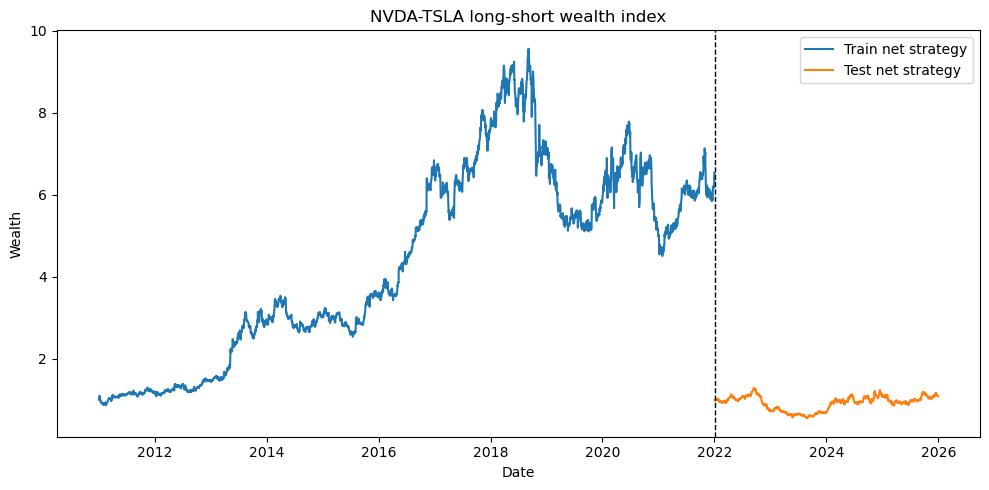

In [8]:
pred_train = results["pred_train"].copy()
pred_test = results["pred_test"].copy()

train_wealth = (1 + pred_train["strategy_net"]).cumprod()
test_wealth = (1 + pred_test["strategy_net"]).cumprod()

plt.plot(pred_train["date"], train_wealth, label="Train net strategy")
plt.plot(pred_test["date"], test_wealth, label="Test net strategy")
plt.axvline(pd.to_datetime(config.TEST_START), color="black", linestyle="--", linewidth=1)

plt.title("NVDA-TSLA long-short wealth index")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.tight_layout()
plt.show()

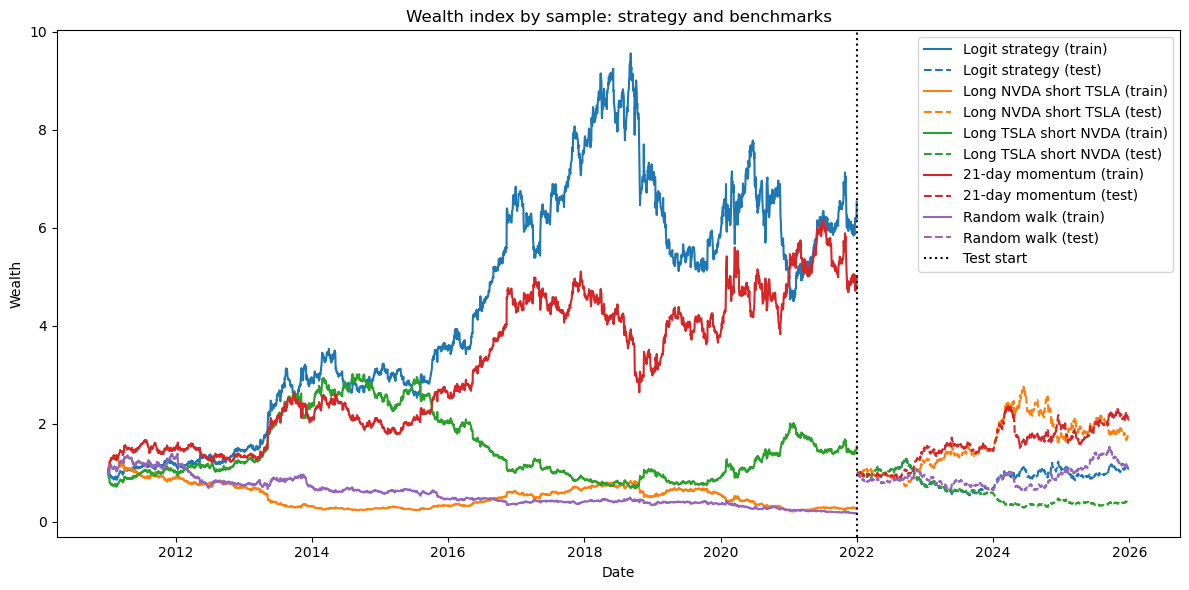

In [9]:
pred_train = results["pred_train"].copy()
pred_test = results["pred_test"].copy()

train_strategy = (1 + pred_train["strategy_net"]).cumprod()
train_nvda_minus_tsla = (1 + pred_train["benchmark_nvda_minus_tsla"]).cumprod()
train_tsla_minus_nvda = (1 + pred_train["benchmark_tsla_minus_nvda"]).cumprod()
train_mom21 = (1 + pred_train["benchmark_mom21"]).cumprod()
train_random_walk = (1 + pred_train["benchmark_random_walk"]).cumprod()

test_strategy = (1 + pred_test["strategy_net"]).cumprod()
test_nvda_minus_tsla = (1 + pred_test["benchmark_nvda_minus_tsla"]).cumprod()
test_tsla_minus_nvda = (1 + pred_test["benchmark_tsla_minus_nvda"]).cumprod()
test_mom21 = (1 + pred_test["benchmark_mom21"]).cumprod()
test_random_walk = (1 + pred_test["benchmark_random_walk"]).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(pred_train["date"], train_strategy, color="C0", linestyle="-", label="Logit strategy (train)")
plt.plot(pred_test["date"], test_strategy, color="C0", linestyle="--", label="Logit strategy (test)")

plt.plot(pred_train["date"], train_nvda_minus_tsla, color="C1", linestyle="-", label="Long NVDA short TSLA (train)")
plt.plot(pred_test["date"], test_nvda_minus_tsla, color="C1", linestyle="--", label="Long NVDA short TSLA (test)")

plt.plot(pred_train["date"], train_tsla_minus_nvda, color="C2", linestyle="-", label="Long TSLA short NVDA (train)")
plt.plot(pred_test["date"], test_tsla_minus_nvda, color="C2", linestyle="--", label="Long TSLA short NVDA (test)")

plt.plot(pred_train["date"], train_mom21, color="C3", linestyle="-", label="21-day momentum (train)")
plt.plot(pred_test["date"], test_mom21, color="C3", linestyle="--", label="21-day momentum (test)")

plt.plot(pred_train["date"], train_random_walk, color="C4", linestyle="-", label="Random walk (train)")
plt.plot(pred_test["date"], test_random_walk, color="C4", linestyle="--", label="Random walk (test)")

plt.axvline(pd.to_datetime(config.TEST_START), color="black", linestyle=":", linewidth=1.5, label="Test start")

plt.title("Wealth index by sample: strategy and benchmarks")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
output_tables = config.ROOT / "outputs" / "tables"
output_figures = config.ROOT / "outputs" / "figures"
output_models = config.ROOT / "outputs" / "models"

print("Tables:")
for p in sorted(output_tables.glob("*")):
    print("-", p.name)

print("\nFigures:")
for p in sorted(output_figures.glob("*")):
    print("-", p.name)

print("\nModels:")
for p in sorted(output_models.glob("*")):
    print("-", p.name)

Tables:
- classification_metrics.csv
- confusion_test.csv
- confusion_train.csv
- logit_coefficients.csv
- portfolio_metrics.csv
- predictions_test.csv
- predictions_train.csv

Figures:
- wealth_curve.png

Models:
- logit_model.joblib


In [11]:
display(pred_test.head())

,date,y,ret_a_next,ret_b_next,spread_next,spread_t,prob_nvda_beats_tsla,signal,turnover,strategy_gross,strategy_net,benchmark_nvda_minus_tsla,benchmark_tsla_minus_nvda,benchmark_mom21_signal,benchmark_mom21,benchmark_random_walk_signal,benchmark_random_walk
0,2022-01-03,1,-0.027608,-0.041833,0.014225,-0.111165,0.483062,-1,0.0,-0.007112,-0.007112,0.007112,-0.007112,-1,-0.007112,-1,-0.007112
1,2022-01-04,0,-0.05757,-0.053471,-0.004099,0.014225,0.483214,-1,0.0,0.002049,0.002049,-0.002049,0.002049,-1,0.002049,1,-0.002049
2,2022-01-05,1,0.020798,-0.021524,0.042322,-0.004099,0.480027,-1,0.0,-0.021161,-0.021161,0.021161,-0.021161,-1,-0.021161,-1,-0.021161
3,2022-01-06,1,-0.033032,-0.035447,0.002414,0.042322,0.480404,-1,0.0,-0.001207,-0.001207,0.001207,-0.001207,-1,-0.001207,1,0.001207
4,2022-01-07,0,0.005626,0.030343,-0.024717,0.002414,0.481737,-1,0.0,0.012358,0.012358,-0.012358,0.012358,-1,0.012358,1,-0.012358


In [12]:
display(pred_test[[
    "date",
    "y",
    "prob_nvda_beats_tsla",
    "signal",
    "strategy_gross",
    "strategy_net",
    "benchmark_nvda_minus_tsla",
    "benchmark_tsla_minus_nvda",
    "benchmark_mom21",
]].head(20))

,date,y,prob_nvda_beats_tsla,signal,strategy_gross,strategy_net,benchmark_nvda_minus_tsla,benchmark_tsla_minus_nvda,benchmark_mom21
0,2022-01-03,1,0.483062,-1,-0.007112,-0.007112,0.007112,-0.007112,-0.007112
1,2022-01-04,0,0.483214,-1,0.002049,0.002049,-0.002049,0.002049,0.002049
2,2022-01-05,1,0.480027,-1,-0.021161,-0.021161,0.021161,-0.021161,-0.021161
3,2022-01-06,1,0.480404,-1,-0.001207,-0.001207,0.001207,-0.001207,-0.001207
4,2022-01-07,0,0.481737,-1,0.012358,0.012358,-0.012358,0.012358,0.012358
5,2022-01-10,1,0.473469,-1,-0.004639,-0.004639,0.004639,-0.004639,-0.004639
6,2022-01-11,0,0.471719,-1,0.016367,0.016367,-0.016367,0.016367,0.016367
7,2022-01-12,1,0.474385,-1,-0.008304,-0.008304,0.008304,-0.008304,-0.008304
8,2022-01-13,0,0.483341,-1,0.001831,0.001831,-0.001831,0.001831,0.001831
9,2022-01-14,0,0.485927,-1,0.010182,0.010182,-0.010182,0.010182,0.010182
